In [1]:
from dask.distributed import LocalCluster

# https://forum.access-hive.org.au/t/netcdf-not-a-valid-id-errors/389/12
cluster = LocalCluster(threads_per_worker=1)          # Fully-featured local Dask cluster
client = cluster.get_client()
client

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39779 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:39779/status,
Dashboard: http://127.0.0.1:39779/status,Workers: 56
Total threads: 56,Total memory: 1.11 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37409,Workers: 56
Dashboard: http://127.0.0.1:39779/status,Total threads: 56
Started: Just now,Total memory: 1.11 TiB
Comm: tcp://127.0.0.1:46857,Total threads: 1
Dashboard: http://127.0.0.1:45033/status,Memory: 20.25 GiB
Nanny: tcp://127.0.0.1:33163,


In [2]:
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import sys
from pathlib import Path
from string import ascii_lowercase, ascii_uppercase

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import HTML, Image, display
from scipy import stats
from cmap import Colormap

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [3]:
def process_daily(ds, deseasonalize=False):
    ds = ds.drop_vars(["var152", "time_bnds", "lat_bnds"], errors="ignore")
    time_arr = ds.time.values
    ds['time'] = pd.to_datetime(np.floor(time_arr), format = '%Y%m%d')
    #ds["time"] = pd.date_range("2021-01", freq="D", periods=ds.time.shape[0])
    ds["plev"] = ds.plev.values / 100.0
    ds["plev"].attrs["units"] = "hPa"
    ds["plev"].attrs["long_name"] = "pressure"
    ds["plev"].attrs["standard_name"] = "pressure"

    if deseasonalize:
        ds = anomalize_func(ds)  # deseasonalize_func(ds)

    return ds#.sel(plev=slice(0.1, 100))

In [4]:
xr.set_options(keep_attrs=True)
rootpath = Path("/sto0/data/Intermediate/Hunga_Tonga_byAles/")
infile_path =rootpath / "ht"
plt.rcParams.update({"font.size": 22})

In [5]:
what = "ta-ua-va_2021-2025.nc"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}"))

In [6]:
ds_w = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_w

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.ht

<xarray.Dataset> Size: 190GB
Dimensions:  (ens: 10, time: 1826, plev: 47, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * plev     (plev) float64 376B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Dimensions without coordinates: ens
Data variables:
    var130   (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1826, 47, 96, 192), meta=np.ndarray>
    v        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1826, 47, 96, 192), meta=np.ndarray>
    u        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1826, 47, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    institution:  Max Planck Institute for Meteorology
    history:      Thu Mar 28 16:15:52 2024: cdo cat Postproc_example-va-paral...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [7]:
ds_wo = xr.open_mfdataset(
    infiles_wo,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_wo

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.ht

<xarray.Dataset> Size: 190GB
Dimensions:  (ens: 10, time: 1826, plev: 47, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * plev     (plev) float64 376B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Dimensions without coordinates: ens
Data variables:
    var130   (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1461, 47, 96, 192), meta=np.ndarray>
    v        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1461, 47, 96, 192), meta=np.ndarray>
    u        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1461, 47, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    institution:  Max Planck Institute for Meteorology
    history:      Thu Mar 28 16:16:11 2024: cdo cat Postproc_example-va-paral...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [46]:
dims4ave = ['lon']
sel_dict = dict(time = slice("2023-09", "2024-04"), plev= slice(0.04,210))
arr1 = ds_w['var130'].sel(**sel_dict).mean(dims4ave)
arr2 = ds_wo['var130'].sel(**sel_dict).mean(dims4ave)
arr1

<xarray.DataArray 'var130' (ens: 10, time: 243, plev: 25, lat: 96)> Size: 23MB
dask.array<mean_agg-aggregate, shape=(10, 243, 25, 96), dtype=float32, chunksize=(1, 243, 25, 96), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2kB 2023-09-01 2023-09-02 ... 2024-04-30
  * plev     (plev) float64 200B 0.04281 0.1112 0.2315 ... 155.8 181.2 208.7
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
Dimensions without coordinates: ens
Attributes:
    code:              130
    table:             128
    CDI_grid_type:     gaussian
    CDI_grid_num_LPE:  48

In [55]:
weights = np.cos(np.deg2rad(ds_w.lat))
weights.name = "weights"

def diff_lat_slice(arr, lat1 = slice(20,0), lat2 = slice(None,60)):
    diff = arr.sel(lat = lat1).weighted(weights).mean('lat')-arr.sel(lat = lat2).weighted(weights).mean('lat')
    return diff

def diff_lat(arr, lat1 = 60, lat2 = 80):
    diff = arr.sel(lat = lat1, method='nearest')-arr.sel(lat = lat2, method='nearest')
    return diff

In [38]:
diff_w = diff_lat_slice(arr1).load()
diff_wo = diff_lat_slice(arr2).load()


/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources

In [56]:
diff_w = diff_lat(arr1).load()
diff_wo = diff_lat(arr2).load()

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [57]:
diff = diff_w.mean('ens')-diff_wo.mean('ens')
#diff

In [58]:
t_stat, p_values = stats.ttest_ind(
    diff_w, diff_wo, equal_var=False
)  # , nan_policy = nan_policy)
diff_t_sel_pcap_pv = xr.DataArray(p_values, coords=diff.coords)

temp-gradient_SOCOL_2023-2024.pdf


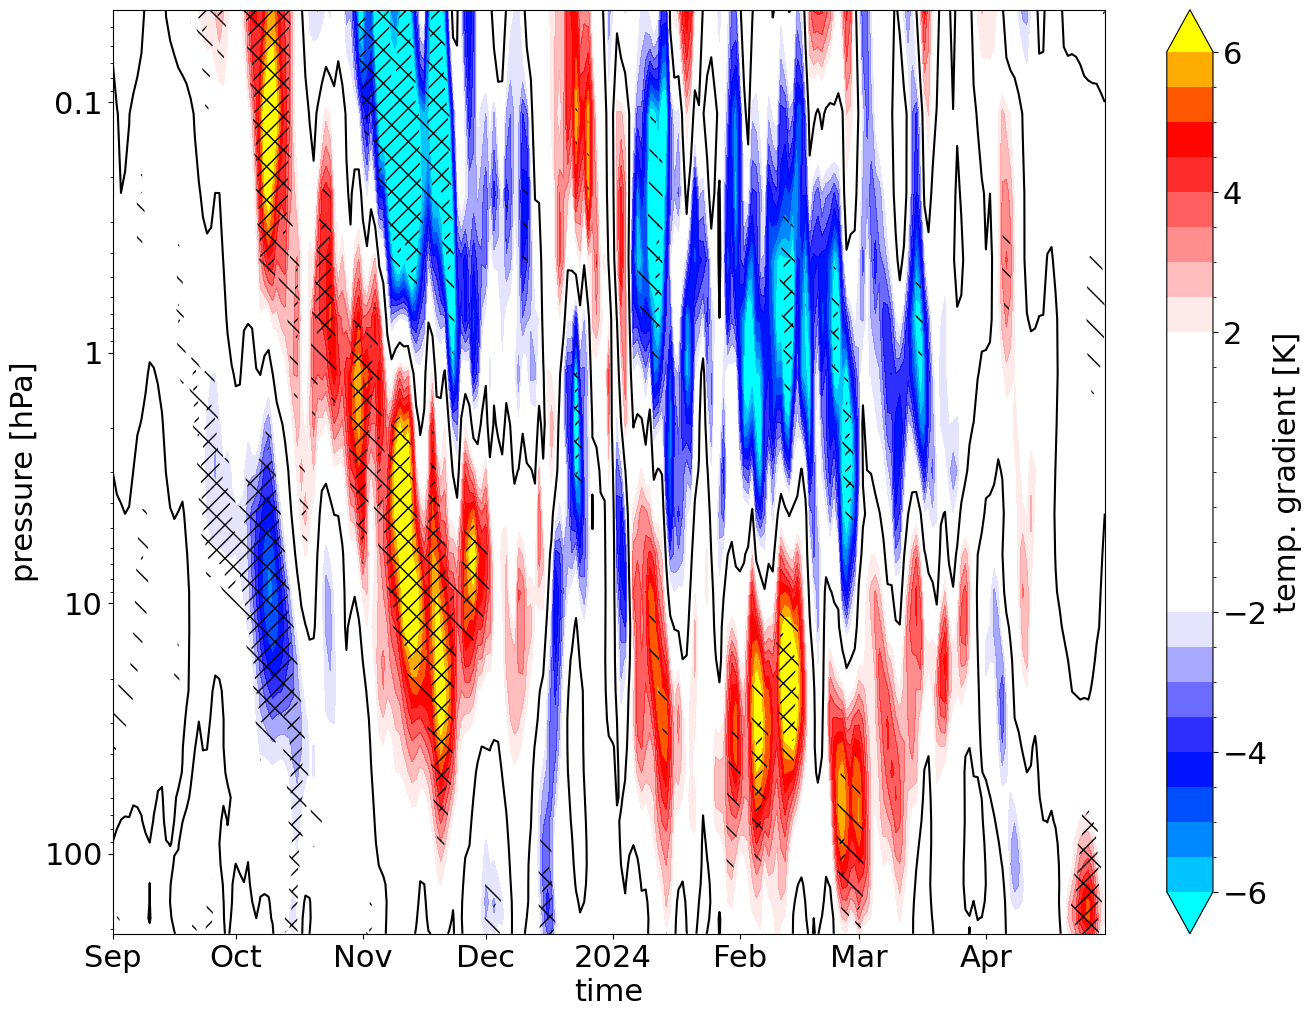

In [59]:
cm = Colormap('vispy:RdYeBuCy')
cmap = cm.to_matplotlib()

p = diff.plot.contourf(
    yincrease = False, 
    size = 12, 
    x = 'time', 
    levels=np.arange(-6,6.5,0.5),
    cmap=cmap,
    cbar_kwargs=dict(
        label=r"temp. gradient [K]",
        ticks = [-6,-4,-2,2,4,6]
    ),
)
ax = p.axes

diff.plot.contour(
    ax = ax,
    colors=('k'),
    levels = [0],
    yincrease = False, 
    x='time',
)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)


ax.set_yscale('log')
ax.set_yticks([100,10,1,0.1])
fmt = mpl.ticker.FormatStrFormatter("%g")
ax.yaxis.set_major_formatter(fmt)

outfile = f"temp-gradient_SOCOL_2023-2024.pdf"
print(outfile)
#plt.savefig(outfile, bbox_inches="tight")

In [48]:
from run_webdav_boku import run_client

client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")


False

In [54]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)

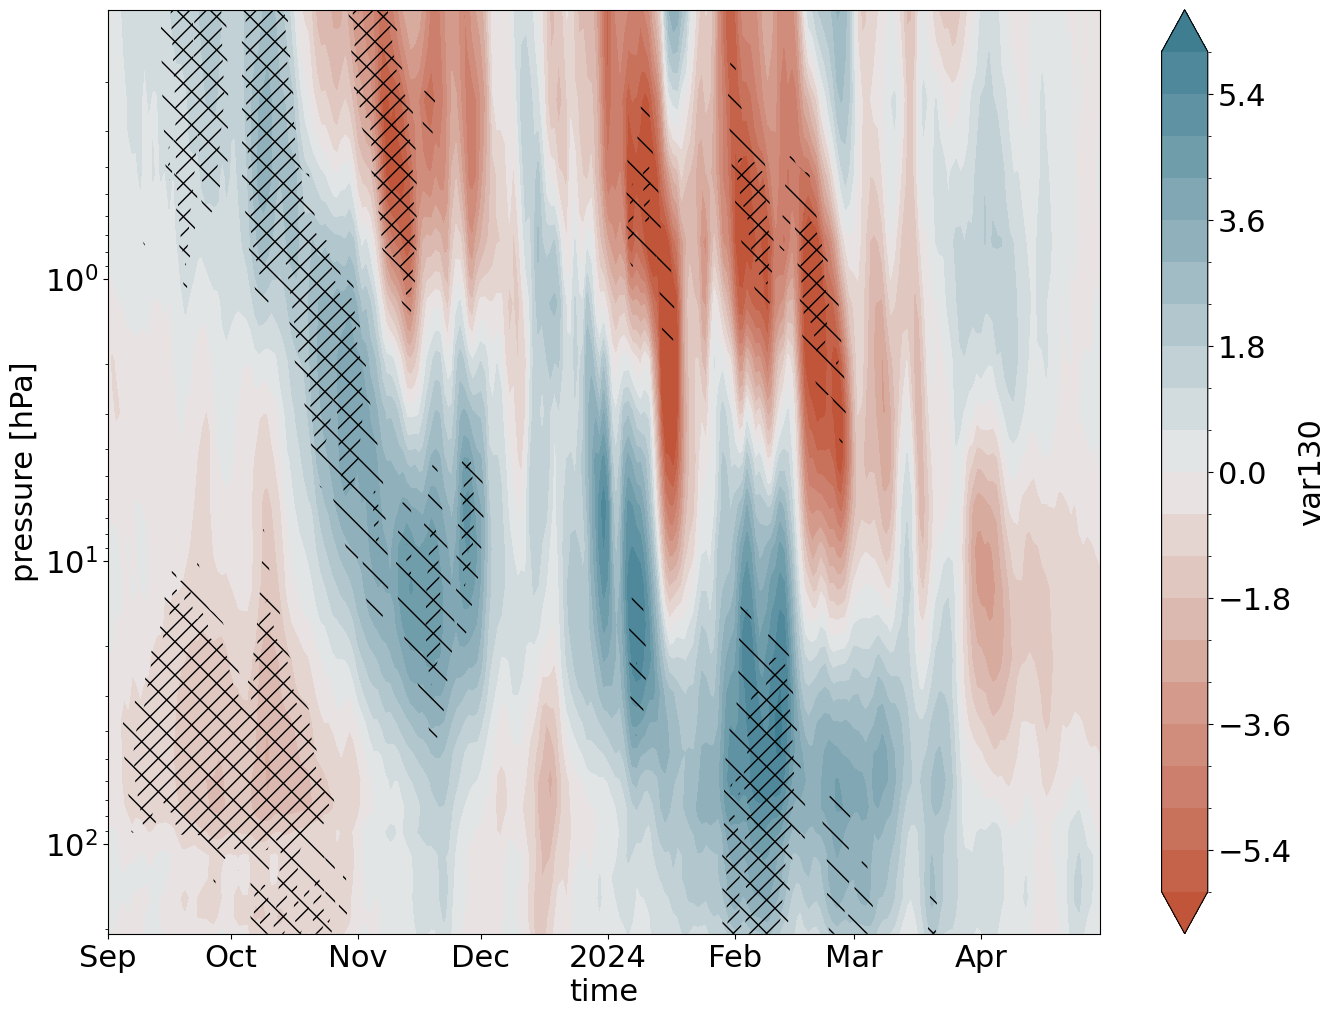

In [26]:
cm = Colormap('vispy:rdbu')
cmap = cm.to_matplotlib()

p = diff.plot.contourf(
    yincrease = 
    False, robust = True, size = 12, x = 'time', 
    levels=21,
    cmap=cmap,
)
ax = p.axes
kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)


plt.yscale('log')

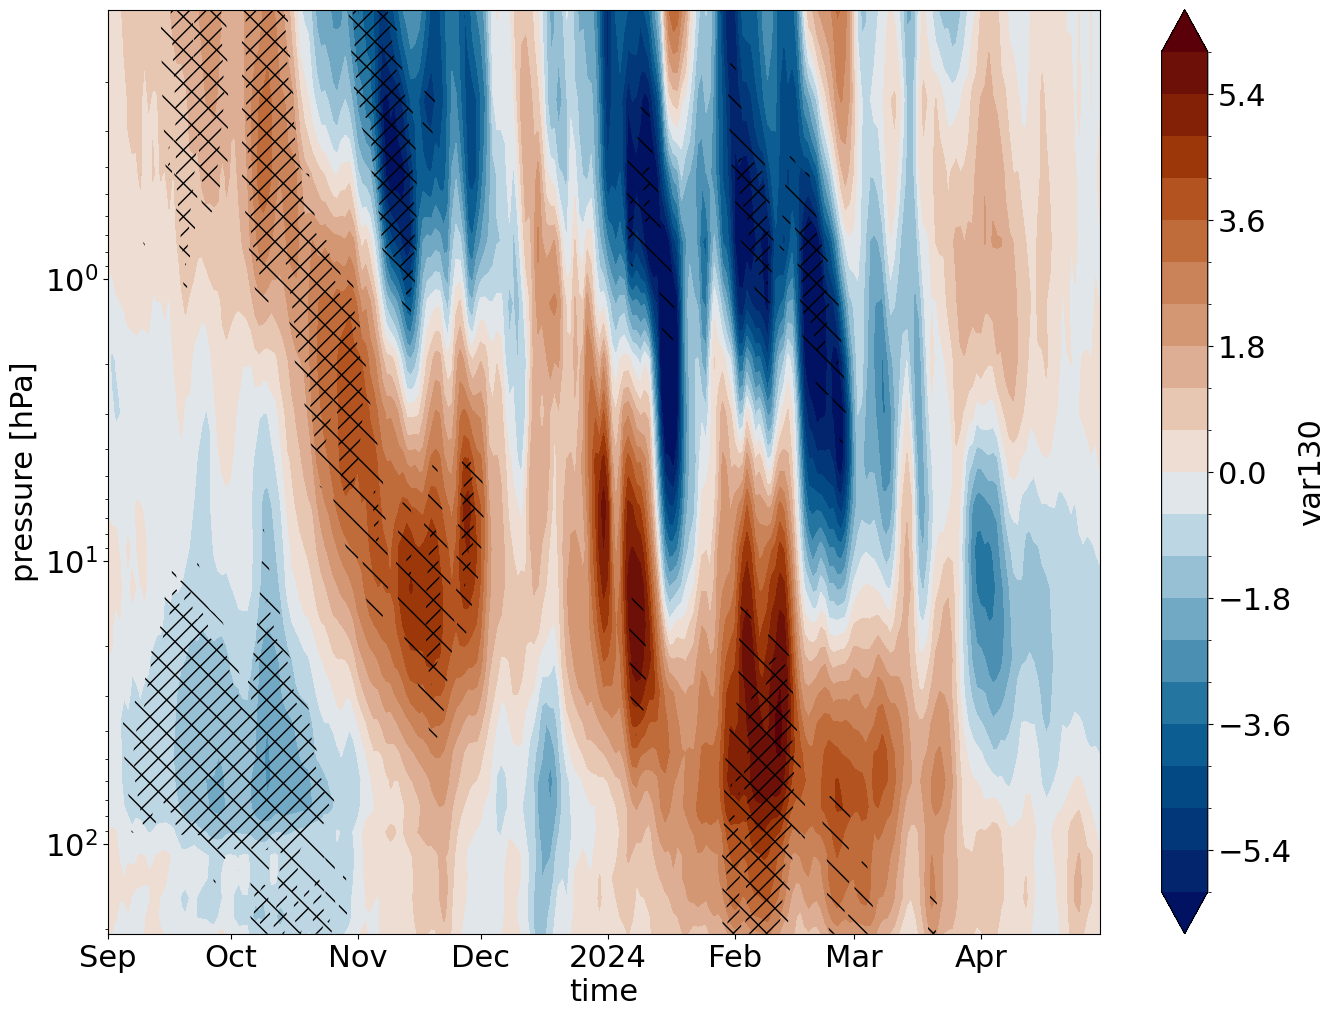

In [32]:
cm = Colormap('crameri:vik')
cmap = cm.to_matplotlib()

p = diff.plot.contourf(
    yincrease = 
    False, robust = True, size = 12, x = 'time', 
    levels=21,
    cmap=cmap,
)
ax = p.axes
kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)


plt.yscale('log')

In [34]:
diff_w = diff_lat_slice(arr1, lat1=slice(40,20)).load()
diff_wo = diff_lat_slice(arr2, lat1=slice(40,20)).load()

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources

In [35]:
diff = diff_w.mean('ens')-diff_wo.mean('ens')
#diff

In [36]:
t_stat, p_values = stats.ttest_ind(
    diff_w, diff_wo, equal_var=False
)  # , nan_policy = nan_policy)
diff_t_sel_pcap_pv = xr.DataArray(p_values, coords=diff.coords)

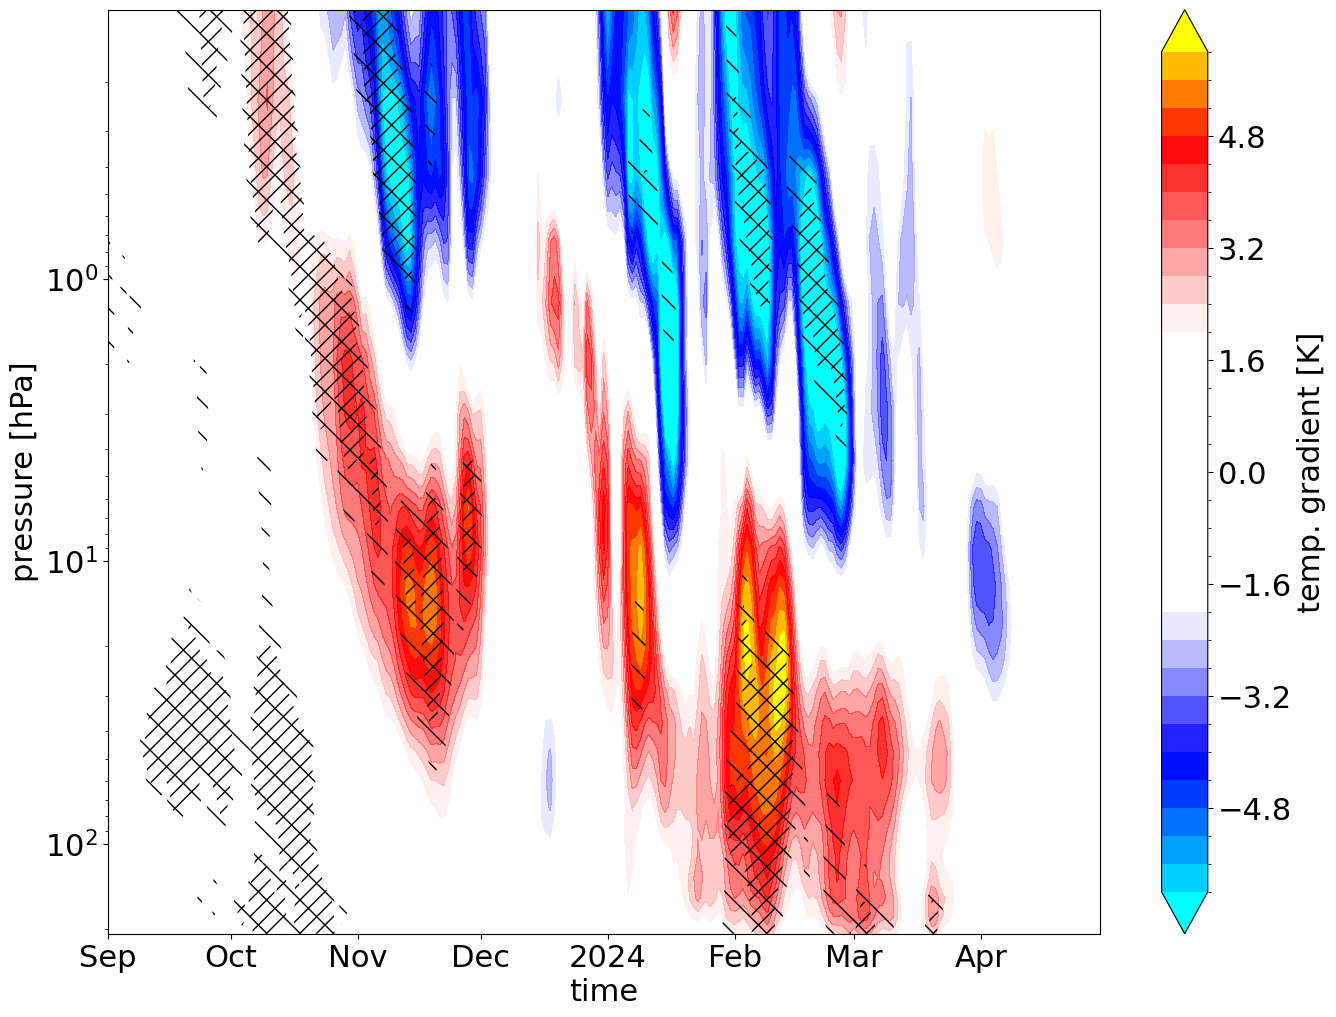

In [37]:
cm = Colormap('vispy:RdYeBuCy')
cmap = cm.to_matplotlib()

p = diff.plot.contourf(
    yincrease = False, 
    vmax = 6, size = 12, x = 'time', 
    levels=31,
    cmap=cmap,
    cbar_kwargs=dict(label=r"temp. gradient [K]"),
)
ax = p.axes
kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)


plt.yscale('log')